# Bridge Micro-Crack Risk Ranking (v2 — National Bridge Inventory)

This version replaces the earlier CA-only structural-inventory file with the
**National Bridge Inventory (NBI)** dataset you uploaded
(`NTAD_National_Bridge_Inventory_....csv`). The NBI is the standard federal
bridge dataset and — unlike the earlier file — it actually contains real
inspection/condition ratings, traffic counts, detour lengths, and scour
ratings, not just structural dimensions.

**Why this notebook does not merge the two files together:** the NBI already
contains every field the earlier CA file had (material, design type, county,
route, lat/lon, year built) *plus* the real condition data the earlier file
was missing. Joining them on bridge number would add fragile string-matching
for no real benefit, so this notebook runs entirely on the NBI file, which is
a strict data upgrade over the earlier proxy-only version.

**Filter applied (per your request):** only bridges built from concrete or
prestressed concrete are kept. Steel, timber, masonry, and "other" are
dropped. In NBI's `STRUCTURE_KIND_043A` material code:

| Code | Material | Kept? |
|---|---|---|
| 1 | Concrete | ✅ |
| 2 | Concrete Continuous | ✅ |
| 5 | Prestressed Concrete | ✅ |
| 6 | Prestressed Concrete Continuous | ✅ |
| 3, 4 | Steel / Steel Continuous | ❌ removed |
| 7, 8, 9, 0 | Wood, Masonry, Iron, Other | ❌ removed |

**Scope:** by default this runs on bridges **nationwide**. Set `STATE_FIPS`
in the next code cell to a specific state's FIPS code (e.g. `'6'` for
California) if you want to restrict it, matching the scope of the earlier run.

**What's new vs. the first version:** the first pass had to exclude "Current
condition/inspection history" (25% of your weight sheet), "Seismic/hazard
exposure" (5%), and "Repair accessibility" (5%) because that data didn't
exist in the file used at the time. The NBI file has real or near-real
proxies for all nine categories, so **none of the sheet's weights need to be
excluded or redistributed this time** — see the weight table below.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

INPUT_CSV = "NTAD_National_Bridge_Inventory_4731338632742650510.csv"
CURRENT_YEAR = 2026
STATE_FIPS = None   # e.g. set to '6' to restrict to California only; None = nationwide

FIPS_TO_ABBR = {
    '1':'AL','2':'AK','4':'AZ','5':'AR','6':'CA','8':'CO','9':'CT','10':'DE',
    '11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN',
    '19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA',
    '26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE','32':'NV',
    '33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND','39':'OH',
    '40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD','47':'TN',
    '48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV','55':'WI',
    '56':'WY','72':'PR','78':'VI'
}

df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig", low_memory=False)
print(f"Loaded {len(df):,} total bridges from the NBI file")

df["STRUCTURE_KIND_043A"] = pd.to_numeric(df["STRUCTURE_KIND_043A"], errors="coerce")
df = df[df["STRUCTURE_KIND_043A"].isin([1, 2, 5, 6])].copy()
print(f"{len(df):,} remain after keeping concrete / prestressed concrete only")

if STATE_FIPS is not None:
    df = df[df["STATE_CODE_001"].astype(str) == str(STATE_FIPS)].copy()
    print(f"{len(df):,} remain after restricting to state FIPS {STATE_FIPS}")

df["STATE_ABBR"] = df["STATE_CODE_001"].astype(str).map(FIPS_TO_ABBR).fillna(df["STATE_CODE_001"].astype(str))


Loaded 624,193 total bridges from the NBI file
434,812 remain after keeping concrete / prestressed concrete only


## Category weights — now fully mapped to real NBI columns

| Sheet category | Weight | NBI column(s) used |
|---|---|---|
| Current condition / inspection history | 25% | `DECK_COND_058`, `SUPERSTRUCTURE_COND_059`, `SUBSTRUCTURE_COND_060`, `STRUCTURAL_EVAL_067` (actual federal inspection ratings, 0=failed to 9=excellent) |
| Material & deterioration mechanism | 15% | `STRUCTURE_KIND_043A` (material) + `DECK_PROTECTION_108C` (epoxy/membrane/cathodic protection) |
| Structural type & criticality | 15% | `STRUCTURE_TYPE_043B` (design type) + `MAIN_UNIT_SPANS_045`/`APPR_SPANS_046` |
| Traffic & structural demand | 10% | `ADT_029` (real traffic counts) + `PERCENT_ADT_TRUCK_109` |
| Age & repair history | 10% | `YEAR_BUILT_027` + `YEAR_RECONSTRUCTED_106` (real reconstruction year, when present) |
| Environmental exposure | 10% | Longitude-based coastal proximity proxy (still approximate — no chloride/freeze-thaw layer exists in NBI either) |
| Seismic / hazard exposure | 5% | `SCOUR_CRITICAL_113` — **this is a scour/flood proxy, not a true seismic hazard rating**; NBI has no seismic field |
| Consequence of disruption/failure | 5% | `DETOUR_KILOS_019` (actual detour length) + `STRAHNET_HIGHWAY_100` (strategic corridor designation) |
| Repair accessibility / suitability | 5% | `UNDWATER_LOOK_SEE_092B` — whether the substructure needs specialized/underwater inspection, used as a rough access-difficulty proxy |

Two caveats worth flagging honestly: the "seismic/hazard" row is really only
scour and flood risk (no seismic data exists in NBI), and "repair
accessibility" is inferred from an inspection-method flag rather than actual
site-access data. Everything else here is a direct or near-direct measurement
rather than a guess.

In [2]:
weights = {
    "current_condition":       0.25,
    "material_deterioration":  0.15,
    "structural_criticality":  0.15,
    "traffic_demand":          0.10,
    "age_repair_history":      0.10,
    "environmental_exposure":  0.10,
    "seismic_hazard":          0.05,
    "consequence_of_failure":  0.05,
    "repair_accessibility":    0.05,
}
assert abs(sum(weights.values()) - 1.0) < 1e-9
print("Category weights (sum to 100%, nothing excluded this time):")
for k, v in weights.items():
    print(f"  {k:25s} {v*100:4.0f}%")


Category weights (sum to 100%, nothing excluded this time):
  current_condition           25%
  material_deterioration      15%
  structural_criticality      15%
  traffic_demand              10%
  age_repair_history          10%
  environmental_exposure      10%
  seismic_hazard               5%
  consequence_of_failure       5%
  repair_accessibility         5%


In [3]:
# --- Current condition / inspection history (25%) ---
# Real federal inspection ratings: 9 = excellent .. 0 = failed. 'N'/'*' mean
# not applicable/not rated and are excluded from that bridge's average rather
# than guessed at.
cond_cols = ["DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060", "STRUCTURAL_EVAL_067"]
cond_numeric = df[cond_cols].apply(pd.to_numeric, errors="coerce")
avg_condition = cond_numeric.mean(axis=1, skipna=True)
avg_condition = avg_condition.fillna(avg_condition.median())
df["current_condition"] = 1 - MinMaxScaler().fit_transform(avg_condition.values.reshape(-1, 1)).ravel()
print(df["current_condition"].describe())


count    434812.000000
mean          0.278656
std           0.110478
min           0.000000
25%           0.222222
50%           0.277778
75%           0.333333
max           1.000000
Name: current_condition, dtype: float64


In [4]:
# --- Material & deterioration mechanism (15%) ---
# Continuity and prestressing add restraint/residual stress that raises
# susceptibility to fine cracking (ASR, chloride ingress, shrinkage,
# prestress/anchorage cracking); protective coatings/membranes reduce it.
material_risk = {1: 0.60, 2: 0.70, 5: 0.80, 6: 0.90}
material_component = df["STRUCTURE_KIND_043A"].map(material_risk).fillna(0.6)

def protection_risk(code):
    c = str(code).strip()
    if c in ("0",):          # no protection
        return 1.0
    if c in ("N", "nan", ""):
        return 0.6           # unknown / not recorded
    return 0.3                # some form of protection present

protection_component = df["DECK_PROTECTION_108C"].apply(protection_risk)
df["material_deterioration"] = 0.7 * material_component + 0.3 * protection_component
print(df["material_deterioration"].describe())


count    434812.000000
mean          0.721323
std           0.105495
min           0.510000
25%           0.650000
50%           0.720000
75%           0.790000
max           0.930000
Name: material_deterioration, dtype: float64


In [5]:
# --- Structural type & criticality (15%) ---
# Less-redundant / more stress-concentrated designs score higher; slabs,
# culverts, and multi-beam designs are more redundant and score lower.
design_risk = {
    0: 0.50, 1: 0.20, 2: 0.30, 3: 0.70, 4: 0.40, 5: 0.40, 6: 0.65, 7: 0.60,
    8: 0.60, 9: 0.65, 10: 0.65, 11: 0.60, 12: 0.60, 13: 0.70, 14: 0.70,
    15: 0.75, 16: 0.75, 17: 0.75, 19: 0.10, 20: 0.50, 21: 0.70, 22: 0.30,
}
design_component = df["STRUCTURE_TYPE_043B"].map(design_risk).fillna(0.5)

span_count = pd.to_numeric(df["MAIN_UNIT_SPANS_045"], errors="coerce").fillna(1) + \
             pd.to_numeric(df["APPR_SPANS_046"], errors="coerce").fillna(0)
span_clipped = span_count.clip(upper=span_count.quantile(0.98))
span_scaled = MinMaxScaler().fit_transform(span_clipped.values.reshape(-1, 1)).ravel()

df["structural_criticality"] = 0.8 * design_component + 0.2 * span_scaled
print(df["structural_criticality"].describe())


count    434812.000000
mean          0.263476
std           0.114452
min           0.080000
25%           0.160000
50%           0.260000
75%           0.340000
max           0.760000
Name: structural_criticality, dtype: float64


In [6]:
# --- Traffic & structural demand (10%) ---
# Real traffic counts this time, not a route-class guess.
adt = pd.to_numeric(df["ADT_029"], errors="coerce").fillna(0)
adt_clipped = adt.clip(upper=adt.quantile(0.98))
adt_scaled = MinMaxScaler().fit_transform(adt_clipped.values.reshape(-1, 1)).ravel()

truck_pct = pd.to_numeric(df["PERCENT_ADT_TRUCK_109"], errors="coerce")
truck_pct = truck_pct.fillna(truck_pct.median())
truck_scaled = MinMaxScaler().fit_transform(truck_pct.values.reshape(-1, 1)).ravel()

df["traffic_demand"] = 0.6 * adt_scaled + 0.4 * truck_scaled
print(df["traffic_demand"].describe())


count    434812.000000
mean          0.092763
std           0.124591
min           0.000000
25%           0.022526
50%           0.047326
75%           0.109052
max           1.000000
Name: traffic_demand, dtype: float64


In [7]:
# --- Age & repair history (10%) ---
# Uses the actual reconstruction year when one is on record: a bridge
# reconstructed in 2015 is treated as effectively 2015-built, not judged
# purely by its original construction year.
year_built = pd.to_numeric(df["YEAR_BUILT_027"], errors="coerce")
year_recon = pd.to_numeric(df["YEAR_RECONSTRUCTED_106"], errors="coerce")
effective_year = np.where((year_recon.notna()) & (year_recon > year_built), year_recon, year_built)
age = (CURRENT_YEAR - effective_year)
age = pd.Series(age, index=df.index).clip(lower=0)
age = age.fillna(age.median())
df["age_repair_history"] = MinMaxScaler().fit_transform(age.values.reshape(-1, 1)).ravel()
print(df["age_repair_history"].describe())


count    434812.000000
mean          0.182723
std           0.106050
min           0.000000
25%           0.097345
50%           0.172566
75%           0.256637
max           1.000000
Name: age_repair_history, dtype: float64


In [8]:
# --- Environmental exposure (10%) ---
# Longitude used as a rough west<->east coastal/chloride-exposure proxy.
# This is NOT a true distance-to-coastline measurement -- NBI has no
# chloride, humidity, or freeze-thaw-cycle data either, so this is carried
# over unchanged from the first version.
lon = pd.to_numeric(df["LONGDD"], errors="coerce")
lon = lon.fillna(lon.median())
df["environmental_exposure"] = MinMaxScaler().fit_transform((-lon).values.reshape(-1, 1)).ravel()
print(df["environmental_exposure"].describe())


count    434812.000000
mean          0.557765
std           0.076848
min           0.000000
25%           0.506270
50%           0.545547
75%           0.585518
max           1.000000
Name: environmental_exposure, dtype: float64


In [9]:
# --- Seismic / hazard exposure (5%) ---
# NBI has no seismic rating at all. SCOUR_CRITICAL_113 is used as a stand-in
# hazard signal (it covers the scour/flooding portion of this category, not
# earthquake hazard): lower numeric rating = more critical/unstable = higher
# risk; 'N' = not over a waterway (low risk); 'U' = unknown foundation
# (treated as moderately risky, since the uncertainty itself is a concern).
def scour_risk(code):
    c = str(code).strip()
    if c == "N":
        return 0.05
    if c == "U":
        return 0.60
    try:
        v = float(c)
        return 1 - (v / 9)
    except ValueError:
        return 0.5

df["seismic_hazard"] = df["SCOUR_CRITICAL_113"].apply(scour_risk)
print(df["seismic_hazard"].describe())


count    434812.000000
mean          0.205616
std           0.181259
min           0.000000
25%           0.111111
50%           0.111111
75%           0.444444
max           1.000000
Name: seismic_hazard, dtype: float64


In [10]:
# --- Consequence of disruption / failure (5%) ---
# Real detour length (km) plus strategic-highway-network designation, which
# roughly captures "emergency-route importance" from the weight sheet.
detour = pd.to_numeric(df["DETOUR_KILOS_019"], errors="coerce").fillna(0)
detour_clipped = detour.clip(upper=detour.quantile(0.98))
detour_scaled = MinMaxScaler().fit_transform(detour_clipped.values.reshape(-1, 1)).ravel()

strahnet = pd.to_numeric(df["STRAHNET_HIGHWAY_100"], errors="coerce").fillna(0)
strahnet_scaled = (strahnet / strahnet.max()) if strahnet.max() > 0 else strahnet * 0

df["consequence_of_failure"] = 0.6 * detour_scaled + 0.4 * strahnet_scaled
print(df["consequence_of_failure"].describe())


count    434812.000000
mean          0.073712
std           0.128410
min           0.000000
25%           0.009045
50%           0.018090
75%           0.078392
max           0.885427
Name: consequence_of_failure, dtype: float64


In [11]:
# --- Repair accessibility / suitability (5%) ---
# UNDWATER_LOOK_SEE_092B flags whether the substructure needs specialized
# (e.g. underwater diving) inspection -- used here as a rough proxy for how
# hard the region would be to access, drill, and inject for a repair crew.
def access_risk(code):
    c = str(code).strip()
    return 1.0 if c.startswith("Y") else 0.2

df["repair_accessibility"] = df["UNDWATER_LOOK_SEE_092B"].apply(access_risk)
print(df["repair_accessibility"].describe())


count    434812.000000
mean          0.239110
std           0.172507
min           0.200000
25%           0.200000
50%           0.200000
75%           0.200000
max           1.000000
Name: repair_accessibility, dtype: float64


In [12]:
AVAILABLE = list(weights.keys())
df["composite_risk_score"] = sum(df[feat] * weights[feat] for feat in AVAILABLE)
print("Composite score summary:")
print(df["composite_risk_score"].describe())


Composite score summary:
count    434812.000000
mean          0.326631
std           0.051114
min           0.143655
25%           0.291232
50%           0.325839
75%           0.361206
max           0.641921
Name: composite_risk_score, dtype: float64


## Unsupervised ML cross-check (Isolation Forest)

There is still no ground-truth "has internal micro-cracks" label anywhere in
this data (no dataset tracks that directly), so a supervised classifier
would need invented labels to train on, which isn't honest. An Isolation
Forest instead flags bridges whose *combination* of the nine proxy features
is statistically unusual relative to the rest of the population — a
secondary diagnostic signal reported alongside the transparent weighted
score above, not a replacement for it.

In [13]:
feature_matrix = df[AVAILABLE].values
iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(feature_matrix)
raw_anomaly = -iso.decision_function(feature_matrix)
df["ml_anomaly_score"] = MinMaxScaler().fit_transform(raw_anomaly.reshape(-1, 1)).ravel()
print("Isolation Forest fit on", feature_matrix.shape[0], "bridges,", feature_matrix.shape[1], "features")


Isolation Forest fit on 434812 bridges, 9 features


In [14]:
df_ranked = df.sort_values("composite_risk_score", ascending=False).reset_index(drop=True)
df_ranked.insert(0, "risk_rank", df_ranked.index + 1)

out_cols = ["risk_rank", "STATE_ABBR", "STRUCTURE_NUMBER_008", "FACILITY_CARRIED_007",
            "FEATURES_DESC_006A", "YEAR_BUILT_027", "STRUCTURE_KIND_043A", "STRUCTURE_TYPE_043B",
            "LATDD", "LONGDD", "ADT_029", "BRIDGE_CONDITION",
            "current_condition", "material_deterioration", "structural_criticality",
            "traffic_demand", "age_repair_history", "environmental_exposure",
            "seismic_hazard", "consequence_of_failure", "repair_accessibility",
            "composite_risk_score", "ml_anomaly_score"]
df_ranked[out_cols].to_csv("bridge_microcrack_risk_ranked_NBI.csv", index=False)
print(f"Wrote bridge_microcrack_risk_ranked_NBI.csv ({len(df_ranked):,} rows)")
print()
print("Top 15 highest-risk bridges:")
print(df_ranked[["risk_rank", "STATE_ABBR", "STRUCTURE_NUMBER_008", "FACILITY_CARRIED_007",
                  "FEATURES_DESC_006A", "composite_risk_score"]].head(15).to_string(index=False))


Wrote bridge_microcrack_risk_ranked_NBI.csv (434,812 rows)

Top 15 highest-risk bridges:
 risk_rank STATE_ABBR STRUCTURE_NUMBER_008 FACILITY_CARRIED_007      FEATURES_DESC_006A  composite_risk_score
         1         TN          150A9090001             NFA A909         NOLICHUKY RIVER              0.641921
         2         TN          300A8940001             NFA A894        NOLICHUCKY RIVER              0.621159
         3         TN          90025690003   NFA 2569 (SA 9004)        NOLICHUCKY RIVER              0.620438
         4         TN          90SR0810003               FAP 81        NOLICHUCKY RIVER              0.620436
         5         TN          860A0680001             NFA A068        NOLICHUCKY RIVER              0.599787
         6         IA      000000000080270                   FM E.FK WAPSIPINICON RIVER              0.594526
         7         TN          86I00260034            I26 LT LN        NOLICHUCKY RIVER              0.588641
         8         PR          

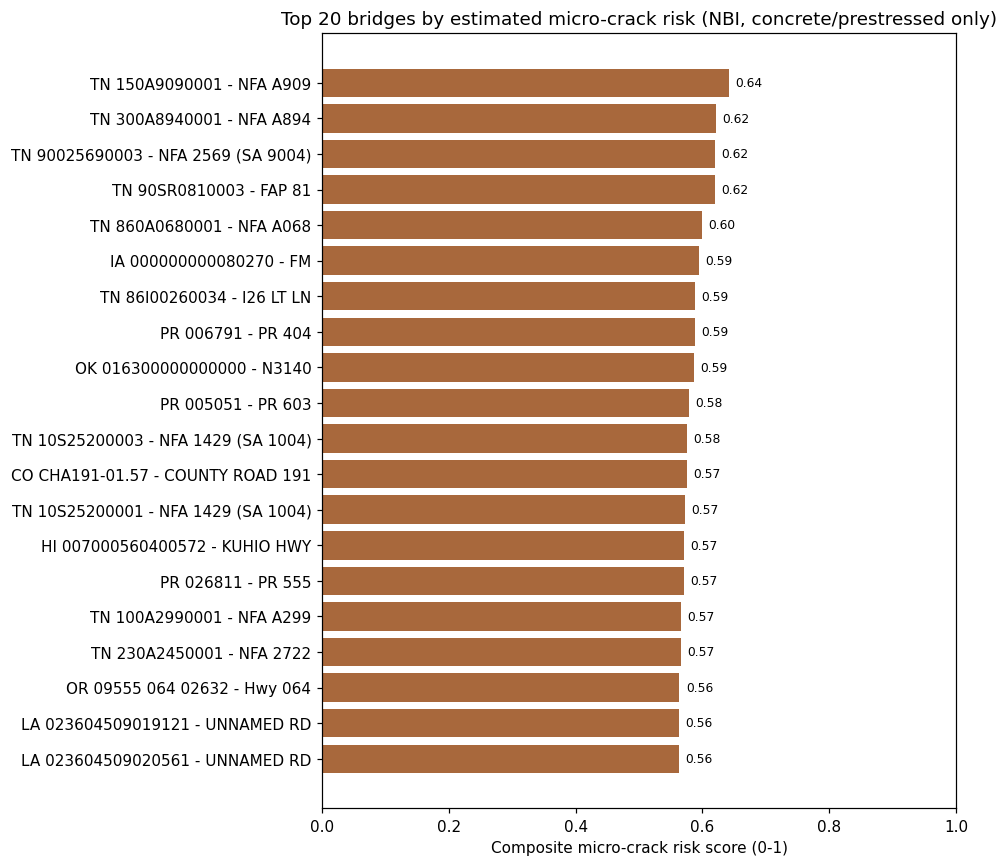

In [15]:
plt.rcParams.update({"font.size": 10})

top20 = df_ranked.head(20).iloc[::-1]
labels = (top20["STATE_ABBR"].astype(str) + " " + top20["STRUCTURE_NUMBER_008"].astype(str)
          + " - " + top20["FACILITY_CARRIED_007"].astype(str).str.slice(0, 20))
fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(labels, top20["composite_risk_score"], color="#A8683C")
ax.set_xlabel("Composite micro-crack risk score (0-1)")
ax.set_title("Top 20 bridges by estimated micro-crack risk (NBI, concrete/prestressed only)")
ax.set_xlim(0, 1)
for bar, val in zip(bars, top20["composite_risk_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("top20_risk_bridges_NBI.png", dpi=150)
plt.show()


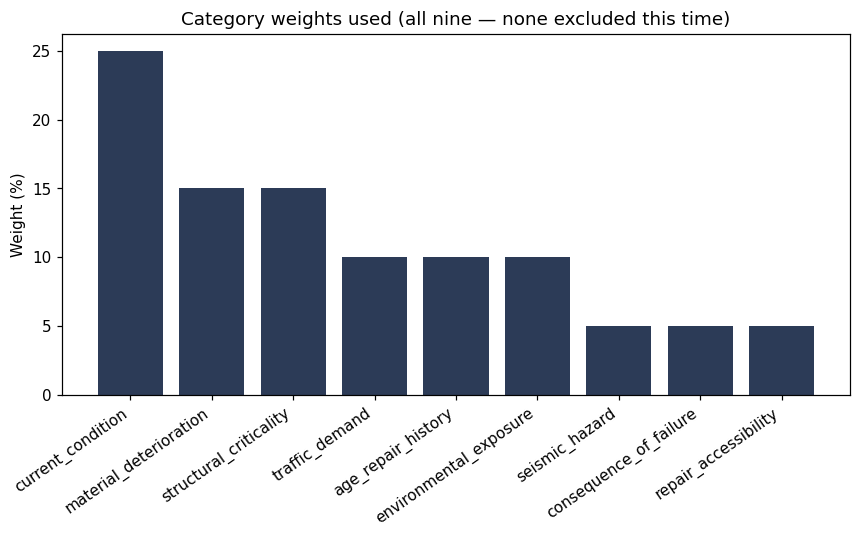

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
cats = list(weights.keys())
vals = [weights[c] * 100 for c in cats]
ax.bar(cats, vals, color="#2C3B57")
ax.set_ylabel("Weight (%)")
ax.set_title("Category weights used (all nine — none excluded this time)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("weight_breakdown_NBI.png", dpi=150)
plt.show()


## Notes / next steps

- Set `STATE_FIPS` in the second code cell to restrict this to one state
  (e.g. `'6'` for California) if you want a smaller, more comparable result
  to the first version.
- "Seismic/hazard exposure" here is really scour/flood risk — if you can
  find a seismic hazard layer (e.g. USGS PGA/seismic design category by
  location), swap it in for a real improvement on that 5%.
- "Repair accessibility" is a weak proxy — if you have any site-access or
  terrain data, that would meaningfully improve that 5%.
- `ml_anomaly_score` is a secondary cross-check; the primary ranking is the
  transparent weighted `composite_risk_score` column.